# Unidad 4 · Flow shop de tres etapas: permutar, y comprobar que no cuesta

**Planta:** Conservas del Itata S.A.
**Datos:** `DatosClases/4_Secuenciamiento/itata_flowshop.csv` — 8 lotes que
recorren PREP → ENVASADO → AUTOCLAVE
**Solver:** Gurobi

---

## Qué se decide aquí

Hasta ahora cada lote pasaba por **una** máquina. Ahora la línea real: cada
lote se prepara, se envasa y se esteriliza, en ese orden y sin saltarse
ninguna etapa. Ocho lotes, tres etapas, 24 operaciones.

Es un **flow shop**: todos los trabajos siguen la misma ruta. (Si cada
trabajo tuviera su propia ruta sería un *job shop*, y —detalle que conviene
notar— el modelo sería **el mismo**: la diferencia entre ambos entornos está
en los datos, no en las restricciones.)

## La pregunta del cuaderno

Un flow shop **permutacional** (`Fm|prmu|Cmax`) exige que **todas** las
máquinas procesen los lotes en el mismo orden. Es una restricción real en
muchas líneas: si no hay espacio de acumulación entre etapas, no se puede
adelantar un lote. Y es también, muchas veces, una simplificación que se
asume sin decirlo, porque reduce el modelo de una binaria por par **y
máquina** a una binaria por par.

La pregunta es qué cuesta esa restricción. Y la respuesta correcta no es
"nada" ni "poco": es **hay que comprobarlo**. Para `m ≤ 3` existe siempre un
óptimo permutacional entre los óptimos generales, así que no cuesta nada y
está demostrado. Para `m ≥ 4` el óptimo permutacional puede ser
**estrictamente peor**. Aquí hay tres etapas, así que se sabe de antemano que
van a coincidir; se resuelven las dos igual, porque el hábito de comprobar
es lo que se está enseñando.

## Cifras de referencia

| resultado | valor |
|---|---|
| cota inferior | **33,50 h** |
| Johnson / CDS (heurística) | **35,00 h** |
| `F3|prmu|Cmax` (óptimo permutacional) | **33,50 h** |
| `F3‖Cmax` (óptimo general) | **33,50 h** |

La cota inferior se alcanza. Eso no siempre pasa, y cuando pasa cierra la
discusión: no hay nada mejor que buscar.

In [1]:
import sys
import time
import itertools
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

fs = pd.read_csv(datos("4_Secuenciamiento", "itata_flowshop.csv"))
fs = fs.sort_values(["lote", "orden_etapa"])

LOTES = list(dict.fromkeys(fs.lote))
ETAPAS = list(dict.fromkeys(fs.sort_values("orden_etapa").etapa))
ruta = {j: [(x.etapa, float(x.p_h)) for x in fs[fs.lote == j].itertuples()]
        for j in LOTES}
p = {(j, k): ruta[j][k][1] for j in LOTES for k in range(len(ETAPAS))}
maquina = {(j, k): ruta[j][k][0] for j in LOTES for k in range(len(ETAPAS))}
m_etapas = len(ETAPAS)

print(f"{len(LOTES)} lotes · {m_etapas} etapas: " + " -> ".join(ETAPAS))
pivot = fs.pivot(index="lote", columns="etapa", values="p_h")[ETAPAS]
print("\nTiempos de proceso (h):\n")
print(pivot.to_string(float_format=lambda v: f"{v:,.1f}"))
print("\nCarga total por etapa (h):")
for e in ETAPAS:
    print(f"  {e:10s} {pivot[e].sum():6.1f}")

8 lotes · 3 etapas: PREP -> ENVASADO -> AUTOCLAVE

Tiempos de proceso (h):

etapa  PREP  ENVASADO  AUTOCLAVE
lote                            
F1      2.0       4.5        3.0
F2      5.5       1.5        4.0
F3      3.5       3.0        2.5
F4      1.0       5.0        6.0
F5      4.5       2.0        1.5
F6      2.5       6.0        3.5
F7      6.0       2.5        5.0
F8      3.0       3.5        2.0

Carga total por etapa (h):
  PREP         28.0
  ENVASADO     28.0
  AUTOCLAVE    27.5


## 1. La cota inferior, con la parte que se suele olvidar

Dos cotas evidentes:

* **Carga de máquina.** Ninguna etapa puede terminar antes de haber procesado
  todo lo que le toca: `Cmax ≥ max_e Σ_j p_je`.
* **Ruta más larga.** Ningún lote termina antes de haber hecho sus tres
  operaciones en serie: `Cmax ≥ max_j Σ_e p_je`.

Y una tercera, que es la que aquí manda. La etapa `e` no puede empezar a
trabajar antes de que **algún** lote haya terminado todo lo que viene antes,
y después de que `e` termine su último lote, ese lote todavía tiene que
recorrer lo que viene después:

$$C_{\max} \;\ge\; \min_j \Big(\sum_{a<e} p_{ja}\Big) \;+\; \sum_j p_{je} \;+\; \min_j \Big(\sum_{a>e} p_{ja}\Big)$$

Los dos `min` son tiempo de máquina inevitablemente ocioso: al principio
esperando al primer lote, al final esperando a que el último se vaya. Sumar
esos dos huecos a la carga es lo que convierte una cota floja en una cota
que, en esta instancia, resulta ser **exacta**.

In [2]:
carga = {e: float(pivot[e].sum()) for e in ETAPAS}
ruta_larga = {j: sum(pp for _e, pp in ruta[j]) for j in LOTES}

lb_carga = max(carga.values())
lb_ruta = max(ruta_larga.values())
lb = max(lb_carga, lb_ruta)

print(f"cota por carga de máquina : {lb_carga:6.2f} h  "
      f"(etapa {max(carga, key=carga.get)})")
print(f"cota por ruta más larga   : {lb_ruta:6.2f} h  "
      f"(lote {max(ruta_larga, key=ruta_larga.get)})")

print("\ncota por etapa, con el ocio inevitable de los extremos:")
for idx, e in enumerate(ETAPAS):
    antes = min(sum(ruta[j][a][1] for a in range(idx)) for j in LOTES)
    despues = min(sum(ruta[j][a][1] for a in range(idx + 1, m_etapas))
                  for j in LOTES)
    valor = antes + carga[e] + despues
    lb = max(lb, valor)
    print(f"  {e:10s}  {antes:5.2f} (antes) + {carga[e]:5.2f} (carga) "
          f"+ {despues:5.2f} (después) = {valor:6.2f} h")

print(f"\nCOTA INFERIOR = {lb:.2f} h")

cota por carga de máquina :  28.00 h  (etapa PREP)
cota por ruta más larga   :  13.50 h  (lote F7)

cota por etapa, con el ocio inevitable de los extremos:
  PREP         0.00 (antes) + 28.00 (carga) +  3.50 (después) =  31.50 h
  ENVASADO     1.00 (antes) + 28.00 (carga) +  1.50 (después) =  30.50 h
  AUTOCLAVE    6.00 (antes) + 27.50 (carga) +  0.00 (después) =  33.50 h

COTA INFERIOR = 33.50 h


## 2. Evaluar una permutación sin solver

Dada una secuencia, el calendario de un flow shop permutacional se construye
de una pasada: cada operación empieza cuando se cumplen sus dos condiciones,
que la máquina esté libre **y** que el lote haya terminado la etapa anterior.

$$\text{inicio}(j, e) = \max(\text{libre}(e), \; \text{fin}(j, e-1))$$

Esa recursión es todo el flow shop permutacional. No hace falta un modelo
para evaluar un orden: el modelo hace falta para **elegirlo**.

In [3]:
def evaluar_permutacion(sec):
    libre = {e: 0.0 for e in ETAPAS}
    fin_lote, asign, C = {}, [], {}
    for pos, j in enumerate(sec, start=1):
        fin_j = 0.0
        for k, (e, pp) in enumerate(ruta[j]):
            ini = max(libre[e], fin_j)
            libre[e] = fin_j = ini + pp
            asign.append({"lote": j, "etapa": e, "k": k, "inicio": ini,
                          "fin": fin_j, "posicion": pos})
        C[j] = fin_j
    return {"Cmax": max(C.values()), "sumC": sum(C.values()), "C": C,
            "asignaciones": pd.DataFrame(asign)}


print(f"Orden del archivo: {' '.join(LOTES)}")
print(f"  Cmax = {evaluar_permutacion(LOTES)['Cmax']:.2f} h  "
      f"(cota inferior {lb:.2f} h)")

Orden del archivo: F1 F2 F3 F4 F5 F6 F7 F8
  Cmax = 37.50 h  (cota inferior 33.50 h)


## 3. Johnson: exacto en dos etapas, heurístico en tres

La regla de Johnson (1954) resuelve `F2‖Cmax` **exactamente**, y su
enunciado es de una simplicidad desconcertante:

> Grupo A: los trabajos con `p1 ≤ p2`, ordenados por `p1` **creciente**.
> Grupo B: el resto, ordenados por `p2` **decreciente**. La secuencia es A + B.

La lógica: al principio conviene alimentar rápido la segunda máquina (por eso
primero los de `p1` chico), y al final conviene que la segunda máquina tenga
poco por hacer (por eso al final los de `p2` chico).

Con **tres** etapas Johnson deja de ser exacto en general. La extensión
clásica agrega las etapas de a pares —`A = p1 + p2`, `B = p2 + p3`— y aplica
Johnson a ese par artificial. Esa transformación es **exacta** si la máquina
del medio está **dominada**:

$$\min_j p_{j1} \ge \max_j p_{j2} \qquad \text{o} \qquad \min_j p_{j3} \ge \max_j p_{j2}$$

Es decir: si ENVASADO nunca es cuello de botella frente a PREP, o nunca lo es
frente a AUTOCLAVE, el problema de tres etapas colapsa a uno de dos. La
condición hay que **comprobarla**, no suponerla, y en estos datos no se
cumple. Johnson sigue siendo utilizable; deja de ser exacto.

In [4]:
def johnson(a, b):
    A = sorted([j for j in LOTES if a[j] <= b[j]], key=lambda j: (a[j], j))
    B = sorted([j for j in LOTES if a[j] > b[j]], key=lambda j: (-b[j], j))
    return A + B


p1 = {j: ruta[j][0][1] for j in LOTES}
p2 = {j: ruta[j][1][1] for j in LOTES}
p3 = {j: ruta[j][2][1] for j in LOTES}

dom_izq = min(p1.values()) >= max(p2.values())
dom_der = min(p3.values()) >= max(p2.values())

print("Condición de dominancia de la etapa del medio (ENVASADO):")
print(f"  min p_PREP      = {min(p1.values()):.1f}  >=  "
      f"max p_ENVASADO = {max(p2.values()):.1f}  ->  {dom_izq}")
print(f"  min p_AUTOCLAVE = {min(p3.values()):.1f}  >=  "
      f"max p_ENVASADO = {max(p2.values()):.1f}  ->  {dom_der}")
print(f"\n  ¿Johnson es exacto aquí? {dom_izq or dom_der}")
print("  No lo es. Lo que sigue es una heurística, y hay que decirlo.")

sec_johnson = johnson({j: p1[j] + p2[j] for j in LOTES},
                      {j: p2[j] + p3[j] for j in LOTES})
ev_johnson = evaluar_permutacion(sec_johnson)
print(f"\nJohnson extendido: {' '.join(sec_johnson)}")
print(f"  Cmax = {ev_johnson['Cmax']:.2f} h")

Condición de dominancia de la etapa del medio (ENVASADO):
  min p_PREP      = 1.0  >=  max p_ENVASADO = 6.0  ->  False
  min p_AUTOCLAVE = 1.5  >=  max p_ENVASADO = 6.0  ->  False

  ¿Johnson es exacto aquí? False
  No lo es. Lo que sigue es una heurística, y hay que decirlo.

Johnson extendido: F4 F1 F6 F7 F2 F3 F8 F5
  Cmax = 35.00 h


### CDS: aplicar Johnson `m − 1` veces

La heurística de Campbell, Dudek y Smith (1970) generaliza la idea. Para cada
`k = 1 … m−1` construye un problema artificial de dos máquinas sumando las
primeras `k` etapas y las últimas `k`, le aplica Johnson, evalúa la secuencia
resultante **en el flow shop verdadero** y se queda con la mejor. Con tres
etapas son dos intentos.

El detalle que hace correcta a CDS: la secuencia se construye sobre el
problema artificial y se **evalúa sobre el real**. Nunca se reporta el valor
del problema artificial, que no significa nada.

In [5]:
filas_cds = []
mejor = None
for k in range(1, m_etapas):
    a = {j: sum(ruta[j][i][1] for i in range(k)) for j in LOTES}
    b = {j: sum(ruta[j][m_etapas - 1 - i][1] for i in range(k)) for j in LOTES}
    sec = johnson(a, b)
    v = evaluar_permutacion(sec)["Cmax"]
    filas_cds.append({"k": k, "secuencia": " ".join(sec), "Cmax": v})
    if mejor is None or v < mejor[0] - 1e-9:
        mejor = (v, sec)
cds = pd.DataFrame(filas_cds)
print(cds.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
cmax_cds, sec_cds = mejor
print(f"\nMejor CDS: {cmax_cds:.2f} h con {' '.join(sec_cds)}")
print(f"Exceso sobre la cota inferior: "
      f"{100*(cmax_cds/lb - 1):.2f} %  ({cmax_cds - lb:.2f} h)")

 k               secuencia  Cmax
 1 F4 F1 F6 F7 F2 F3 F8 F5 35.00
 2 F4 F1 F6 F7 F2 F3 F8 F5 35.00

Mejor CDS: 35.00 h con F4 F1 F6 F7 F2 F3 F8 F5
Exceso sobre la cota inferior: 4.48 %  (1.50 h)


## 4. Enumeración: cuántas permutaciones hay y cuántas son buenas

Con 8 lotes hay `8! = 40 320` permutaciones. Es poco, así que se pueden
evaluar todas y ver la distribución completa. Esto no es un método —con 12
lotes ya son 479 millones— pero permite ver algo que el solver nunca muestra:
**cuán raro es el óptimo**.

In [6]:
t0 = time.perf_counter()
valores = [evaluar_permutacion(s)["Cmax"] for s in itertools.permutations(LOTES)]
seg_enum = time.perf_counter() - t0
valores = np.array(valores)
cmax_enum = valores.min()

print(f"{len(valores):,} permutaciones evaluadas en {seg_enum:.1f} s")
print(f"  mejor  : {valores.min():.2f} h")
print(f"  peor   : {valores.max():.2f} h")
print(f"  media  : {valores.mean():.2f} h")
print(f"  óptimas: {int((valores <= cmax_enum + 1e-9).sum())} de {len(valores):,} "
      f"({100*(valores <= cmax_enum + 1e-9).mean():.3f} %)")
print(f"\nEl peor orden dura un {100*(valores.max()/cmax_enum - 1):.1f} % más que "
      f"el mejor, y el promedio un {100*(valores.mean()/cmax_enum - 1):.1f} % más.")
print("Elegir el orden al azar no es catastrófico, y tampoco es gratis: son")
print(f"{valores.mean() - cmax_enum:.2f} h de línea por semana.")

40,320 permutaciones evaluadas en 13.6 s
  mejor  : 33.50 h
  peor   : 47.50 h
  media  : 39.73 h
  óptimas: 352 de 40,320 (0.873 %)

El peor orden dura un 41.8 % más que el mejor, y el promedio un 18.6 % más.
Elegir el orden al azar no es catastrófico, y tampoco es gratis: son
6.23 h de línea por semana.


## 5. `F3|prmu|Cmax`: el modelo permutacional

La formulación **disyuntiva**. Variable de inicio por operación:

$$S_{jk} = \text{instante en que empieza la } k\text{-ésima etapa del lote } j$$

Tres bloques de restricciones:

1. **Ruta:** `S[j,k+1] ≥ S[j,k] + p[j,k]`. Un lote no se envasa antes de
   prepararse.
2. **Recurso:** para cada par de lotes, uno va antes que el otro **en todas
   las etapas a la vez**. Una sola binaria `x[a,b]` por par, reutilizada en
   las tres etapas: eso es lo que significa "permutacional".
3. **Objetivo:** `Cmax ≥ S[j, última] + p[j, última]`.

El big-M es `Σ p`, la duración de hacer todo en serie sin solapar nada:
válido, y en un flow shop no muy flojo, porque las operaciones sí se
encadenan de verdad.

In [7]:
H = sum(p.values())
print(f"big-M = Σ p = {H:.1f} h")


def resolver(permutacion, tiempo_limite=120.0):
    m = gp.Model("F3-prmu" if permutacion else "F3-general")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = 1e-9
    m.Params.Seed = 0

    S = m.addVars(list(p), lb=0.0, ub=H, name="S")

    # (1) precedencias de ruta
    for j in LOTES:
        for k in range(m_etapas - 1):
            m.addConstr(S[j, k + 1] >= S[j, k] + p[j, k], name=f"ruta[{j},{k}]")

    # (2) disyunciones de recurso
    if permutacion:
        pares = [(a, b) for i, a in enumerate(LOTES) for b in LOTES[i + 1:]]
        x = m.addVars(pares, vtype=GRB.BINARY, name="x")
        for (a, b) in pares:
            for k in range(m_etapas):
                # la MISMA binaria en las tres etapas: un único orden global
                m.addConstr(S[b, k] >= S[a, k] + p[a, k] - H * (1 - x[a, b]),
                            name=f"perm1[{a},{b},{k}]")
                m.addConstr(S[a, k] >= S[b, k] + p[b, k] - H * x[a, b],
                            name=f"perm2[{a},{b},{k}]")
    else:
        por_maquina = {}
        for (j, k), e in maquina.items():
            por_maquina.setdefault(e, []).append((j, k))
        pares = [(e, a, b) for e, lst in por_maquina.items()
                 for i, a in enumerate(lst) for b in lst[i + 1:]]
        x = m.addVars(pares, vtype=GRB.BINARY, name="x")
        for (e, a, b) in pares:
            # una binaria por par Y POR MAQUINA: cada etapa elige su orden
            m.addConstr(S[b] >= S[a] + p[a] - H * (1 - x[e, a, b]),
                        name=f"disy1[{e},{a},{b}]")
            m.addConstr(S[a] >= S[b] + p[b] - H * x[e, a, b],
                        name=f"disy2[{e},{a},{b}]")

    Cmax = m.addVar(lb=0.0, ub=H, name="Cmax")
    m.addConstrs((Cmax >= S[j, m_etapas - 1] + p[j, m_etapas - 1]
                  for j in LOTES), name="cmax")
    m.setObjective(Cmax, GRB.MINIMIZE)

    t0 = time.perf_counter()
    m.optimize()
    seg = time.perf_counter() - t0

    asign = pd.DataFrame([
        {"lote": j, "etapa": maquina[j, k], "k": k, "inicio": S[j, k].X,
         "fin": S[j, k].X + p[j, k]} for (j, k) in p])
    return {"modelo": m, "Cmax": m.ObjVal, "cota": m.ObjBound,
            "gap_%": 100 * m.MIPGap, "seg": seg, "vars": m.NumVars,
            "binarias": m.NumBinVars, "restr": m.NumConstrs,
            "nodos": int(m.NodeCount), "asignaciones": asign,
            "estado": "OPTIMAL" if m.Status == GRB.OPTIMAL else str(m.Status)}


sol_prmu = resolver(permutacion=True)
sol_gen = resolver(permutacion=False)

comp = pd.DataFrame([
    {"modelo": "F3|prmu|Cmax", "Cmax": sol_prmu["Cmax"], "estado": sol_prmu["estado"],
     "gap_%": sol_prmu["gap_%"], "variables": sol_prmu["vars"],
     "binarias": sol_prmu["binarias"], "restricciones": sol_prmu["restr"],
     "nodos": sol_prmu["nodos"], "segundos": sol_prmu["seg"]},
    {"modelo": "F3||Cmax (general)", "Cmax": sol_gen["Cmax"], "estado": sol_gen["estado"],
     "gap_%": sol_gen["gap_%"], "variables": sol_gen["vars"],
     "binarias": sol_gen["binarias"], "restricciones": sol_gen["restr"],
     "nodos": sol_gen["nodos"], "segundos": sol_gen["seg"]},
])
print(comp.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

big-M = Σ p = 83.5 h
Restricted license - for non-production use only - expires 2027-11-29


            modelo   Cmax  estado  gap_%  variables  binarias  restricciones  nodos  segundos
      F3|prmu|Cmax 33.500 OPTIMAL  0.000         53        28            192    788     0.449
F3||Cmax (general) 33.500 OPTIMAL  0.000        109        84            192   2516     3.082


## 6. La comparación que había que hacer

El general tiene tres veces las binarias del permutacional —una por par y por
etapa en vez de una por par— y su región factible **contiene** a la del
permutacional: toda solución permutacional es una solución general, no al
revés. Por lo tanto `F3‖Cmax ≤ F3|prmu|Cmax` **siempre**, y la pregunta es si
la desigualdad es estricta.

In [8]:
resumen_cmax = pd.DataFrame([
    {"método": "cota inferior", "Cmax": lb, "exceso_%": 0.0},
    {"método": "orden del archivo", "Cmax": evaluar_permutacion(LOTES)["Cmax"],
     "exceso_%": 100 * (evaluar_permutacion(LOTES)["Cmax"] / lb - 1)},
    {"método": "Johnson extendido", "Cmax": ev_johnson["Cmax"],
     "exceso_%": 100 * (ev_johnson["Cmax"] / lb - 1)},
    {"método": "CDS (mejor de 2)", "Cmax": cmax_cds,
     "exceso_%": 100 * (cmax_cds / lb - 1)},
    {"método": "enumeración de las 8! permutaciones", "Cmax": float(cmax_enum),
     "exceso_%": 100 * (cmax_enum / lb - 1)},
    {"método": "MIP F3|prmu|Cmax", "Cmax": sol_prmu["Cmax"],
     "exceso_%": 100 * (sol_prmu["Cmax"] / lb - 1)},
    {"método": "MIP F3||Cmax general", "Cmax": sol_gen["Cmax"],
     "exceso_%": 100 * (sol_gen["Cmax"] / lb - 1)},
])
# El solver devuelve 33.499999997: redondear antes de imprimir evita que la
# tabla muestre un "-0.00 %" que solo existe en el ultimo bit del flotante.
resumen_cmax["Cmax"] = resumen_cmax["Cmax"].round(6)
resumen_cmax["exceso_%"] = resumen_cmax["exceso_%"].round(4) + 0.0
print(resumen_cmax.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

print(f"\nPermutacional = {sol_prmu['Cmax']:.2f} h,  "
      f"general = {sol_gen['Cmax']:.2f} h,  "
      f"diferencia = {abs(sol_gen['Cmax'] - sol_prmu['Cmax']):.2f} h.")
print("Permutar no cuesta nada AQUÍ, y eso era esperable: para m <= 3 está")
print("demostrado que existe un óptimo permutacional. La comprobación no")
print("sobraba, sobra la suposición.")
print(f"\nJohnson y CDS quedan a {cmax_cds - lb:.2f} h "
      f"({100*(cmax_cds/lb - 1):.2f} %) del óptimo: son heurísticas y en estos")
print("datos la condición de dominancia no se cumple, así que no había ninguna")
print("razón para esperar que acertaran.")

                             método  Cmax  exceso_%
                      cota inferior 33.50      0.00
                  orden del archivo 37.50     11.94
                  Johnson extendido 35.00      4.48
                   CDS (mejor de 2) 35.00      4.48
enumeración de las 8! permutaciones 33.50      0.00
                   MIP F3|prmu|Cmax 33.50      0.00
               MIP F3||Cmax general 33.50      0.00

Permutacional = 33.50 h,  general = 33.50 h,  diferencia = 0.00 h.
Permutar no cuesta nada AQUÍ, y eso era esperable: para m <= 3 está
demostrado que existe un óptimo permutacional. La comprobación no
sobraba, sobra la suposición.

Johnson y CDS quedan a 1.50 h (4.48 %) del óptimo: son heurísticas y en estos
datos la condición de dominancia no se cumple, así que no había ninguna
razón para esperar que acertaran.


### Por qué `m ≥ 4` cambia el cuadro

El argumento que hace válida la permutación con dos o tres máquinas es un
intercambio local: si dos lotes adyacentes están en distinto orden en dos
máquinas consecutivas, se pueden reordenar sin empeorar el makespan, y ese
reordenamiento se propaga. Con cuatro etapas el argumento se rompe: adelantar
un lote en la tercera máquina puede aprovechar un hueco que el orden global
no permitía, y existen instancias donde el óptimo permutacional es
**estrictamente peor** que el general.

Por eso la restricción `prmu` hay que justificarla con **la planta** —¿hay o
no hay espacio de acumulación entre etapas?— y no con la conveniencia del
modelo. Si la línea física permite adelantar un lote y el modelo lo prohíbe,
el plan que sale es factible pero no es el mejor que la planta podía hacer, y
nadie se va a enterar.

## 7. El diagrama de Gantt

Aquí se ve por qué la cota inferior de la sección 1 era exacta: la etapa
cuello de botella trabaja **sin un solo hueco** desde que empieza hasta que
termina, y los únicos tiempos muertos son el arranque y el cierre, que es
exactamente lo que la cota sumaba.

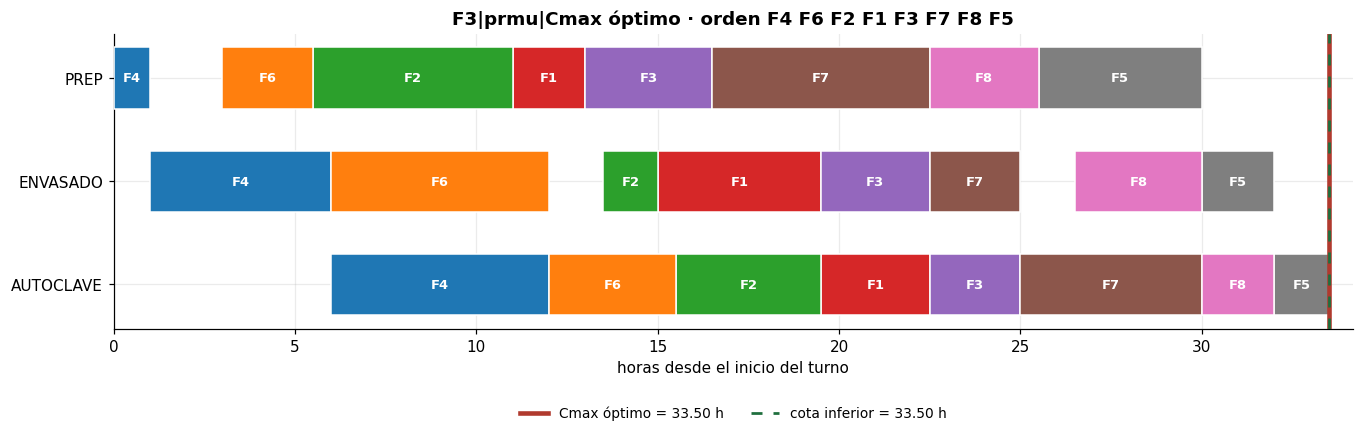

Ocio interno de cada etapa (entre su primera y su última operación):

  PREP       trabaja 28.00 h en una ventana de 30.00 h ->   2.00 h de ocio interno
  ENVASADO   trabaja 28.00 h en una ventana de 31.00 h ->   3.00 h de ocio interno
  AUTOCLAVE  trabaja 27.50 h en una ventana de 27.50 h ->   0.00 h de ocio interno


In [9]:
asig = sol_prmu["asignaciones"].copy()
orden_lotes = (asig[asig.k == 0].sort_values("inicio").lote.tolist())
pos = {j: i for i, j in enumerate(orden_lotes)}
mapa = plt.get_cmap("tab10")
color_lote = {j: mapa(i % 10) for i, j in enumerate(orden_lotes)}

fig, ax = plt.subplots(figsize=(12.5, 4.2))
for _, fila in asig.iterrows():
    y = ETAPAS.index(fila.etapa)
    ax.barh(y, fila.fin - fila.inicio, left=fila.inicio, height=0.6,
            color=color_lote[fila.lote], edgecolor="white", linewidth=1.0,
            zorder=3)
    ax.text(fila.inicio + (fila.fin - fila.inicio) / 2, y, fila.lote,
            ha="center", va="center", color="white", fontsize=8.5,
            fontweight="bold", zorder=4)

ax.set_yticks(range(m_etapas))
ax.set_yticklabels(ETAPAS)
ax.invert_yaxis()
ax.set_xlim(0, sol_prmu["Cmax"] * 1.02)
ax.set_xlabel("horas desde el inicio del turno")
# El Cmax se dibuja primero y la cota encima: al coincidir, se ve la linea roja
# con el trazo verde discontinuo sobre ella, que es justamente lo que se quiere
# mostrar -- el optimo toca la cota.
ax.axvline(sol_prmu["Cmax"], color="#b03a2e", lw=3.0, zorder=5,
           label=f"Cmax óptimo = {sol_prmu['Cmax']:.2f} h")
ax.axvline(lb, color="#1f6f3d", lw=1.8, ls=(0, (4, 4)), zorder=6,
           label=f"cota inferior = {lb:.2f} h")
ax.set_title(f"F3|prmu|Cmax óptimo · orden {' '.join(orden_lotes)}")
ax.legend(fontsize=9, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.22))
ax.grid(axis="x", alpha=0.25)

figura(fig, "gantt_flowshop")
plt.show()

# ocio de cada etapa entre su primera y su ultima operacion
print("Ocio interno de cada etapa (entre su primera y su última operación):\n")
for e in ETAPAS:
    sub = asig[asig.etapa == e].sort_values("inicio")
    span = sub.fin.max() - sub.inicio.min()
    ocio = span - sub.apply(lambda f: f.fin - f.inicio, axis=1).sum()
    print(f"  {e:10s} trabaja {carga[e]:5.2f} h en una ventana de {span:5.2f} h "
          f"->  {ocio:5.2f} h de ocio interno")

## 8. Comprobación

In [10]:
print("Comprobación:")
ok = []
ok.append(verificar(lb, 33.50, "cota inferior (h)", tol=1e-9))
ok.append(verificar(ev_johnson["Cmax"], 35.00, "Johnson extendido (h)", tol=1e-9))
ok.append(verificar(cmax_cds, 35.00, "CDS (h)", tol=1e-9))
ok.append(verificar(sol_prmu["Cmax"], 33.50, "F3|prmu|Cmax (h)", tol=1e-6))
ok.append(verificar(sol_gen["Cmax"], 33.50, "F3||Cmax general (h)", tol=1e-6))
ok.append(verificar(float(cmax_enum), 33.50,
                    "mejor de las 8! permutaciones (h)", tol=1e-9))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

# La cota inferior tiene que serlo, y aqui ademas se alcanza.
assert sol_gen["Cmax"] >= lb - 1e-6, "el óptimo no puede estar bajo la cota"
# El general nunca puede ser peor que el permutacional.
assert sol_gen["Cmax"] <= sol_prmu["Cmax"] + 1e-6, \
    "F3||Cmax no puede ser peor que F3|prmu|Cmax: su región factible lo contiene"
# En m <= 3 ademas tienen que coincidir.
assert abs(sol_gen["Cmax"] - sol_prmu["Cmax"]) < 1e-6, \
    "con 3 etapas debe existir un óptimo permutacional"
# La enumeracion completa confirma al solver permutacional.
assert abs(cmax_enum - sol_prmu["Cmax"]) < 1e-6, \
    "la enumeración de las 8! permutaciones debe coincidir con el MIP permutacional"
# El modelo general es mas grande.
assert sol_gen["binarias"] == m_etapas * sol_prmu["binarias"], \
    "el general debe tener una binaria por par Y por etapa"
# El calendario del solver es un calendario valido: se reconstruye y se mide.
recalc = asig.groupby("lote").fin.max().max()
assert abs(recalc - sol_prmu["Cmax"]) < 1e-6, \
    "el Cmax del calendario debe coincidir con el que reporta el solver"
for e in ETAPAS:
    sub = asig[asig.etapa == e].sort_values("inicio")
    for a, b in zip(sub.itertuples(), list(sub.itertuples())[1:]):
        assert b.inicio >= a.fin - 1e-6, f"solapamiento en la etapa {e}"
for j in LOTES:
    sub = asig[asig.lote == j].sort_values("k")
    for a, b in zip(sub.itertuples(), list(sub.itertuples())[1:]):
        assert b.inicio >= a.fin - 1e-6, f"ruta violada en el lote {j}"
print("Calendario verificado: sin solapamientos y con la ruta respetada.")

tabla(resumen_cmax, "flowshop_metodos")
tabla(asig.sort_values(["etapa", "inicio"]), "flowshop_programa_optimo")
tabla(comp, "flowshop_formulaciones")
resumen({"cota_inferior": float(lb), "johnson": float(ev_johnson["Cmax"]),
         "cds": float(cmax_cds), "enumeracion": float(cmax_enum),
         "F3_prmu": float(sol_prmu["Cmax"]), "F3_general": float(sol_gen["Cmax"]),
         "binarias_prmu": sol_prmu["binarias"],
         "binarias_general": sol_gen["binarias"],
         "orden_optimo": orden_lotes},
        "resumen_flowshop")
print("\nGuardado en resultados/")

Comprobación:
  [  OK  ] cota inferior (h): obtenido 33.5000 | referencia 33.5000 | dif. relativa 0.00e+00
  [  OK  ] Johnson extendido (h): obtenido 35.0000 | referencia 35.0000 | dif. relativa 0.00e+00
  [  OK  ] CDS (h): obtenido 35.0000 | referencia 35.0000 | dif. relativa 0.00e+00
  [  OK  ] F3|prmu|Cmax (h): obtenido 33.5000 | referencia 33.5000 | dif. relativa 0.00e+00
  [  OK  ] F3||Cmax general (h): obtenido 33.5000 | referencia 33.5000 | dif. relativa 1.03e-10
  [  OK  ] mejor de las 8! permutaciones (h): obtenido 33.5000 | referencia 33.5000 | dif. relativa 0.00e+00

6/6 comprobaciones correctas
Calendario verificado: sin solapamientos y con la ruta respetada.

Guardado en resultados/


---

## Para llevarse

1. **`prmu` es una restricción de la planta, no una comodidad del modelo.**
   Si la línea tiene acumulación entre etapas y el modelo prohíbe adelantar
   un lote, el plan sale factible y subóptimo, y nadie se entera. Preguntar
   si hay o no hay espacio entre etapas es parte de levantar los datos.
2. **Aquí permutar no cuesta nada, y aun así había que comprobarlo.** Para
   `m ≤ 3` existe siempre un óptimo permutacional; para `m ≥ 4` el óptimo
   permutacional puede ser estrictamente peor. El resultado depende del número
   de etapas, así que la respuesta correcta nunca es "asumamos que da igual".
3. **Una cota inferior que se alcanza cierra la discusión.** 33,50 h es el
   óptimo y además es imposible hacerlo mejor: no hay que seguir buscando ni
   comprar nada. Ese es el tipo de afirmación que solo se puede hacer con una
   cota en la mano.
4. **Johnson es exacto en dos etapas y una heurística en tres.** La condición
   de dominancia de la máquina del medio es lo que decide cuál de las dos
   cosas es, y se comprueba en dos líneas. Aquí no se cumple y el resultado se
   ve: 35,00 h contra 33,50 h.
5. **Flow shop y job shop son el mismo modelo.** Lo que cambia es que en el
   flow shop todas las rutas coinciden. Escribir dos modelos para eso es
   duplicar el código y duplicar los errores.

## Ejercicios

1. El cuaderno enumeró las `8! = 40 320` permutaciones en pocos segundos.
   Estime cuánto tardaría con 12 lotes y con 15. ¿En qué punto deja de ser
   una opción? Compárelo con el tiempo del MIP.
2. Construya una instancia de **cuatro** etapas en que el óptimo permutacional
   sea estrictamente peor que el general. Pista: necesita que a una máquina
   intermedia le convenga adelantar un lote corto. Verifique resolviendo los
   dos modelos.
3. Modifique los tiempos de ENVASADO para que la etapa quede dominada
   (`min p_PREP ≥ max p_ENVASADO`). Vuelva a correr: ¿Johnson acierta ahora el
   óptimo? ¿Se cumple lo que el teorema promete?
4. Cambie el objetivo a `ΣCj` en ambos modelos. ¿Sigue coincidiendo el
   permutacional con el general? El resultado de `m ≤ 3` está demostrado para
   `Cmax`; no lo dé por válido para otro objetivo sin comprobarlo.
5. Agregue fechas comprometidas a los 8 lotes y minimice `ΣTj` en el flow
   shop. Compare el tiempo del solver con el de `Cmax`. ¿Qué objetivo es más
   caro de resolver y por qué?